In [29]:
from brian2 import *
sys.path.append('Neuron and Synapse Models')
from neuronModels import *
from ringAttractorClass import *

sys.path.append('Tools')
from plottingTools import *
from utils import *

In [30]:
# Setting network parameters
num_neurons = 120
tau=10*ms
sigma_noise=0.0*mV
V_rest=-70*mV

In [31]:
# Creating the equation object
neuron_eq = Equations(LIF_xi_vel_eq, tau=tau, V_rest=V_rest, sigma_noise=sigma_noise)

In [32]:
# Connectivity parameters - Cosine
g_cosine = 0.1*mV
w_inh = -0.555*mV

# Create neuron group
Vth=-48*mV
V_reset=-80*mV
refractory_period=5*ms
glob_inh_flag = True
            
ringAttractor = RingAttractor(neuron_eq, 
                        num_neurons, 
                        Vth, V_reset, refractory_period,
                        syn_profile='cosine',
                        autapse=True,
                        glob_inh=glob_inh_flag, w_inh=w_inh,
                        g_cosine=g_cosine)

# Define run_regularly calls
ringAttractor.ring_pool.run_regularly('V = clip(V, -80*mV, inf*volt)', dt=defaultclock.dt)

CodeRunner(clock=Clock(dt=100. * usecond, name='ring_neurons_run_regularly_clock_4'), when=start, order=0, name='ring_neurons_run_regularly')

In [33]:
def runSimulation(ringAttractor, device = None, dt=0.1*ms,
                    inputParams = None, inputType='Uniform',
                    velInput = 0.0, runTime=50*ms, plot=False):
    
    
    if device == 'cpp_standalone':
        device.reinit()
        device.activate()
        set_device(device, build_on_run=False)

    # Define simulation parameters
    defaultclock.dt = dt
    
    # Define Inputs

    I0 = inputParams.get('I0', 0) * mV
    targetPosition = inputParams.get('targetPosition', 0) # Consider this is in degrees

    # Calculate external input based on input type
    I_ext_array = np.zeros(ringAttractor.numNeurons) * mV
    if inputType == 'Gaussian':
        # Original Gaussian input
        stimulus_center = np.deg2rad(targetPosition) % (2*np.pi)  # Convert degrees to radians
        stimulus_width = 0.5  # width in radians
        
        d = arctan2(sin(ringAttractor.positions - stimulus_center), cos(ringAttractor.positions - stimulus_center))
        I_ext_array += I0 * np.exp(-(d**2) / (2 * stimulus_width**2))
    
    elif inputType == 'Uniform':
        # Equal input to all neurons
        I_ext_array += np.ones(ringAttractor.numNeurons) * I0

        target_index = ringAttractor._get_neuron_index(targetPosition, in_degrees=True)
        I_ext_array[target_index] += inputParams.get('I_target', 1.0)*mV

    ringAttractor.ring_pool.I_ext = I_ext_array

    # # Define run_regularly calls
    # ringAttractor.ring_pool.run_regularly('V = clip(V, V_reset, inf*volt)', dt=defaultclock.dt)

    # Define Monitors
    # By default include a spike monitor
    ringAttractor.spikeMonitor = SpikeMonitor(ringAttractor.ring_pool)
    localObjects = [ringAttractor.spikeMonitor]

    # Generate Brian Network
    net = Network(ringAttractor.BrianObjects + localObjects)

    # Run the simulation
    
    ringAttractor.ring_pool.I_ext = I_ext_array
    ringAttractor.ring_synapses_asym.vel_in = velInput  # Default velocity input for asymmetrical synapses
    ringAttractor.ring_synapses_asym.vel_on = False
    net.run(500*ms) # Run for initial transient
    
    I_ext_array[target_index] -= inputParams.get('I_target', 1.0)*mV
    ringAttractor.ring_pool.I_ext = I_ext_array
    ringAttractor.ring_synapses_asym.vel_on = True
    net.run(runTime)
    simTime = runTime + 500*ms
    
    if device == 'cpp_standalone':
        device.build(directory = 'internalSim_build', compile=True, run=True, debug=False, clean=False)
    
    firingRates = computeInstRate(ringAttractor.spikeMonitor, ringAttractor.numNeurons, meanISI = True)
    
    pva_angle, pva_magnitude = computePVA(firingRates, ringAttractor.positions)
    
    if plot:
        raster_plot(ringAttractor.spikeMonitor,duration=simTime, num_neurons=ringAttractor.numNeurons, y_axisFull=True)

    return pva_angle, pva_magnitude
    

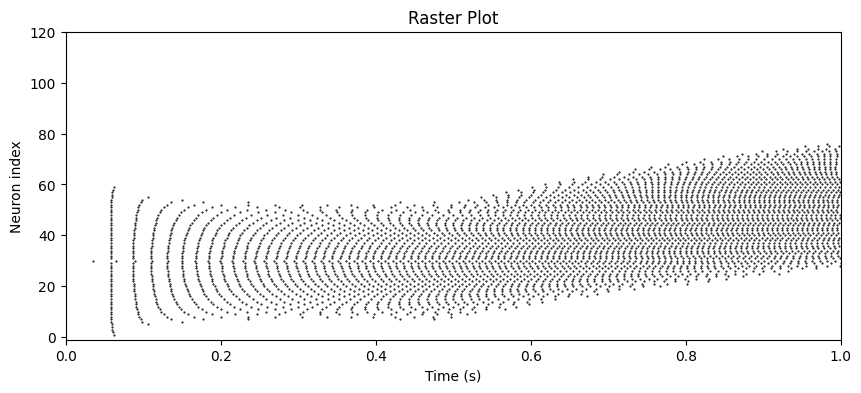

In [34]:
dt = 0.1*ms
inputParams = {'I0': 22.00, 'targetPosition': 90.0, 'I_target': 1.0}
velocityInput = -0.1

pva_angle, pva_magnitude = runSimulation(ringAttractor=ringAttractor, device = None, dt=dt,
            inputParams = inputParams, inputType='Uniform',
            velInput = velocityInput, runTime=500*ms, plot = True)